[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_08/Practica/MISIS4825_Laboratorio08_Practica.ipynb)

# Laboratorio 08 - Práctica: Redes Neuronales Convolucionales

## Objetivos

- Entender los fundamentos y la arquitectura de las redes neuronales convolucionales (CNN).
- Implementar una red convolucional simple para clasificación de imágenes.
- Conocer el funcionamiento de capas clave: Conv2D, Pooling, Dropout, Flatten y Dense.
- Hacer una búsqueda de hiperparámetros.
- Entrenar, evaluar y comparar los modelos, analizando el impacto de cada componente.


## Contexto

En esta práctica de laboratorio trabajaremos con el conjunto de datos **Face Emotion Dataset** para clasificar imágenes de emociones de personas.

**Datos:** [Face Emotion Dataset](https://www.kaggle.com/datasets/nishchalchandel/raf-db-face-emotion-dataset/)

# Descarga y preparación del dataset

En la práctica anterior vimos cómo se puede descargar un dataset utilizando la API de Kaggle. Esta vez lo vamos a hacer de forma más sencilla utilizando `curl` y `subprocess`

In [ ]:
from pathlib import Path
import subprocess # https://docs.python.org/3/library/subprocess.html#subprocess.run

data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
zip_path = data_dir / "raf-db-face-emotion-dataset.zip"
url = "https://www.kaggle.com/api/v1/datasets/download/nishchalchandel/raf-db-face-emotion-dataset"

In [ ]:
subprocess.run(["curl", "-L", "-o", str(zip_path), url], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
subprocess.run(["unzip", "-o", str(zip_path), "-d", str(data_dir)], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
zip_path.unlink(missing_ok=True)

# Exploración de los datos

Podemos ver la distribución de las imágenes de entrenamiento y algunos ejemplos, para ver cómo se distribuyen nuestros datos. De Kaggle ya sabemos que hay tres subconjuntos, de entrenamiento, validacion y prueba, pero veamos la distribucion por clase de entrenamiento en primer lugar.

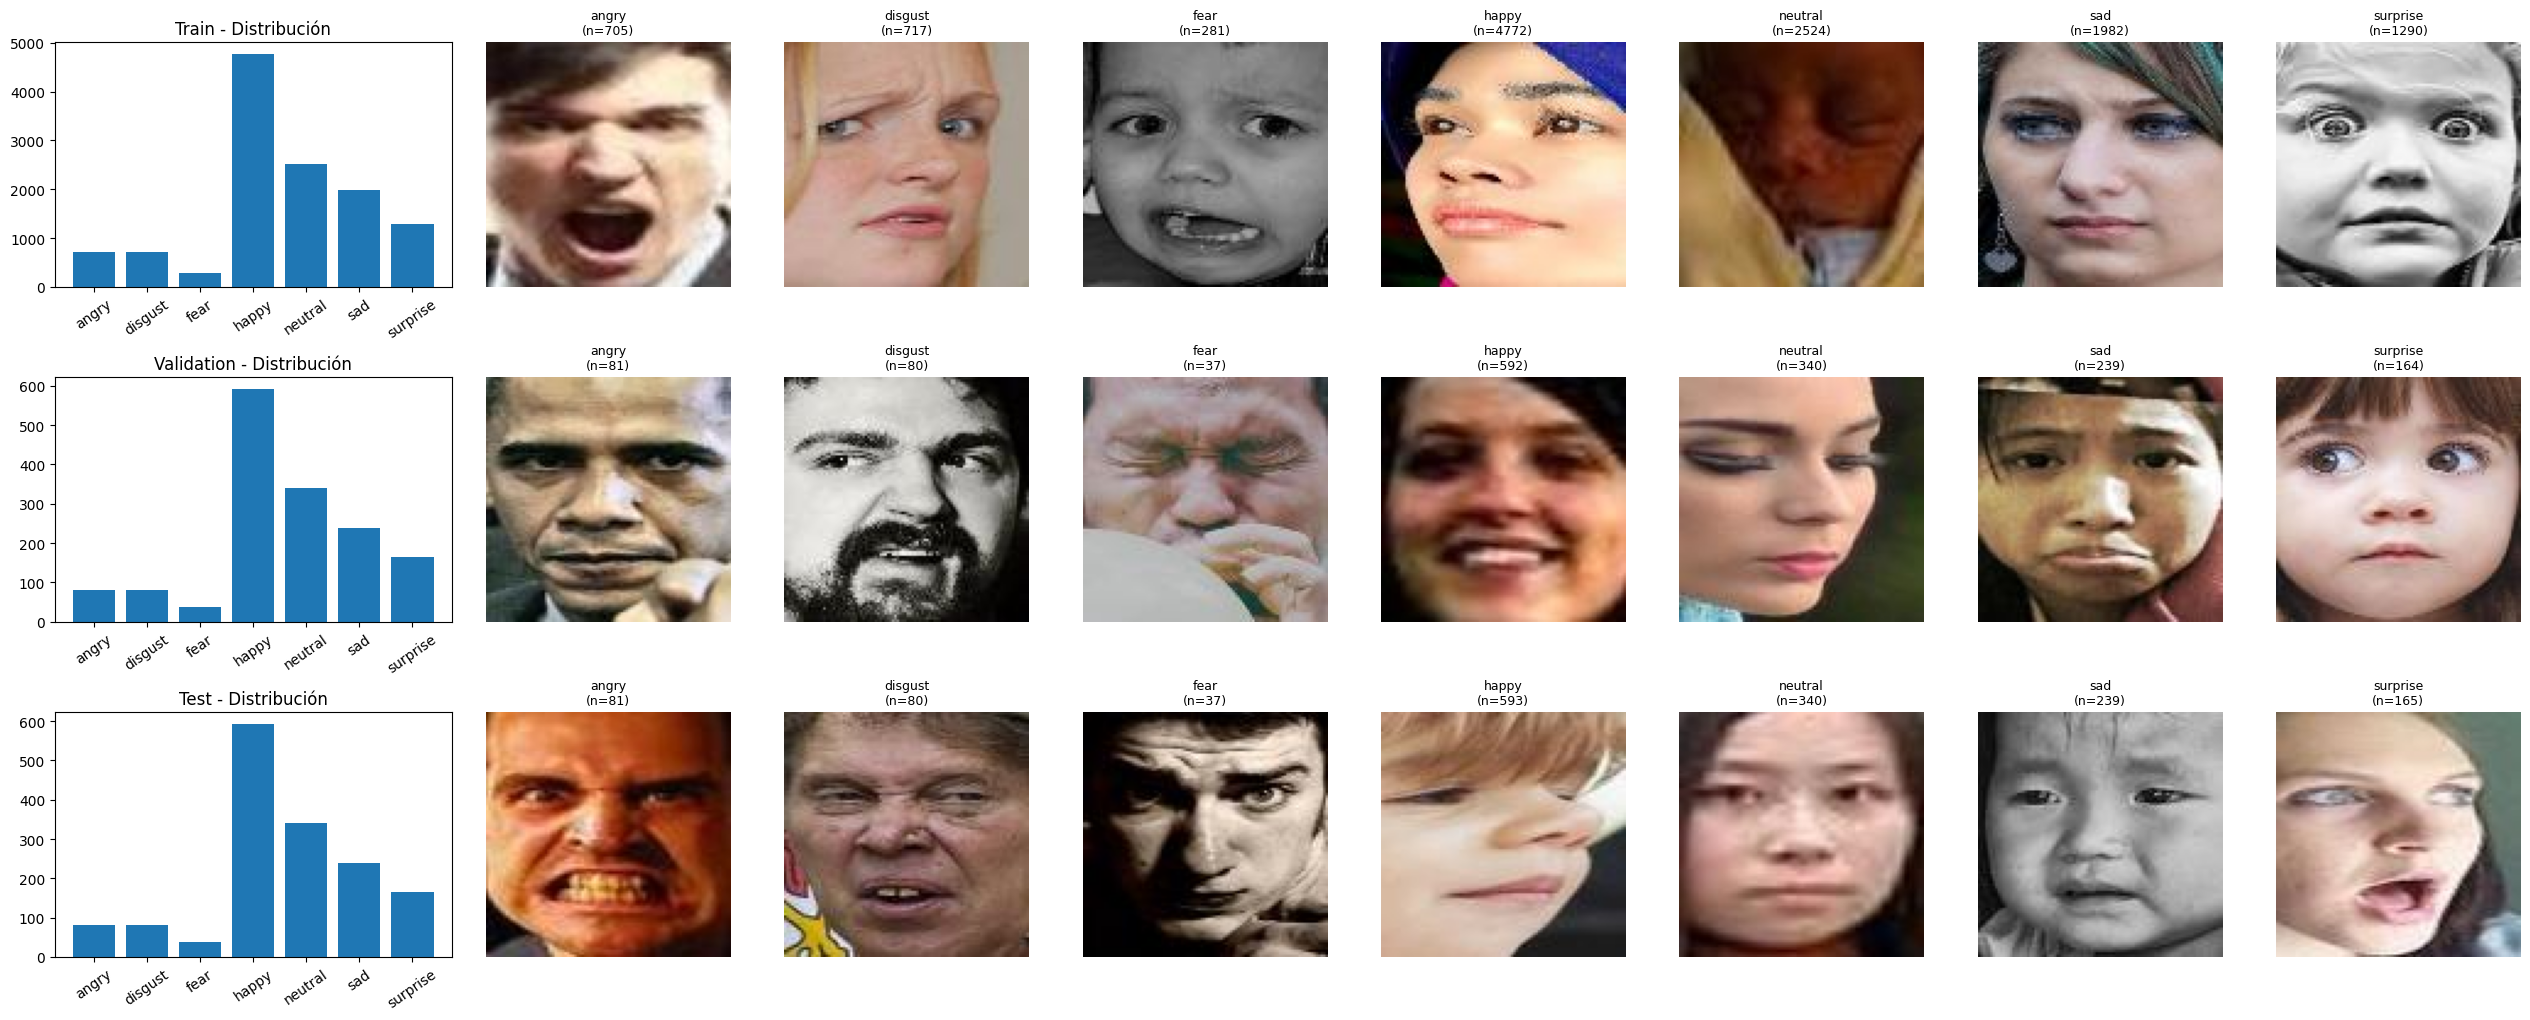

In [ ]:
import matplotlib.pyplot as plt

train_path = data_dir / "train"
test_path = data_dir / "test"
validation_path = data_dir / "validation"

splits = {
    "Train": train_path,
    "Validation": validation_path,
    "Test": test_path,
}

split_data = {}
max_classes = 0

for split_name, split_path in splits.items():
    class_dirs = sorted([d for d in Path(split_path).iterdir() if d.is_dir()])
    labels, counts, samples = [], [], []

    for d in class_dirs:
        imgs = sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() == ".jpg"])
        if imgs:
            labels.append(d.name)
            counts.append(len(imgs))
            samples.append(imgs[0])

    split_data[split_name] = (labels, counts, samples)
    max_classes = max(max_classes, len(labels))

fig = plt.figure(figsize=(3.2 * (max_classes + 1), 3.4 * len(splits)))
gs = fig.add_gridspec(len(splits), max_classes + 1, width_ratios=[1.4] + [1] * max_classes)

for r, (split_name, (labels, counts, samples)) in enumerate(split_data.items()):
    ax_bar = fig.add_subplot(gs[r, 0])
    ax_bar.bar(labels, counts)
    ax_bar.set_title(f"{split_name} - Distribución")
    ax_bar.tick_params(axis="x", rotation=35)

    for c in range(max_classes):
        ax_img = fig.add_subplot(gs[r, c + 1])
        if c < len(labels):
            ax_img.imshow(plt.imread(samples[c]))
            ax_img.set_title(f"{labels[c]}\n(n={counts[c]})", fontsize=9)
        ax_img.axis("off")

plt.tight_layout()
plt.show()


# Preprocesamiento

A continuación construiremos nuestros datasets de entrenamiento prueba y validación. Se crean DataFrames con las rutas de los archivos y sus etiquetas (la etiqueta se infiere del nombre de la carpeta). Anteriormente vimos en las distribuciones que los conjuntos están desbalanceados, para manejar esto hay muchas opciones, tales como hacer muestreos de los datos, aumentaciones, etc. De esto nos encargaremos más adelante.

**Nota:** En este laboratorio no se aplican transformaciones complejas (como ecualización de histograma o filtros), sino que solo se reescala la imagen. En la discusión se analizará qué efectos podría tener aplicar técnicas adicionales de preprocesamiento.


In [ ]:
import pandas as pd

def build_dataframe(root_path):
    filepaths = [str(p) for p in root_path.rglob("*.jpg")]
    labels = [p.parent.name for p in map(Path, filepaths)]
    return pd.DataFrame({"filepath": filepaths, "label": labels})

train_df = build_dataframe(train_path)
test_df = build_dataframe(test_path)
validation_df = build_dataframe(validation_path)

def split_y(df, column):
    return df.drop(column, axis=1), df[column]

X_train, y_train = split_y(train_df, 'label')
X_val, y_val = split_y(validation_df, 'label')
X_test, y_test = split_y(test_df, 'label')

Se utilizan los generadores de datos de Keras para cargar las imágenes en tiempo real.

- Para el conjunto de entrenamiento se aplica data augmentation (rotación, volteo) para mejorar la robustez del modelo.
- Para validación y test, solo se reescala la imagen.
- Se calculan también los pesos de las clases. Esto es con el fin de que el modelo le "preste más atención" a las clases con menos muestras, con el fin de contrarrestar el desbalance que existe.

In [ ]:
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

def make_flow(datagen, X_split, y_split, shuffle):
    df = X_split.copy()
    df["label"] = y_split.values
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        target_size=(100, 100),
        color_mode="grayscale",
        class_mode="categorical",
        classes=labels,
        batch_size=32,
        shuffle=shuffle,
        seed=42,
    )

train = make_flow(train_datagen, X_train, y_train, shuffle=True)
val = make_flow(eval_datagen, X_val, y_val, shuffle=False)
test = make_flow(eval_datagen, X_test, y_test, shuffle=False)

classes = np.unique(y_train.values)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = dict(zip(classes, weights))

Found 12271 validated image filenames belonging to 7 classes.
Found 1533 validated image filenames belonging to 7 classes.
Found 1535 validated image filenames belonging to 7 classes.


## Construcción del Modelo
Se implementa una red neuronal convolucional simple con las siguientes capas:

- `Conv2D:` Aplica filtros aprendibles para extraer características de la imagen.
- `Pooling (MaxPooling2D):` Reduce la dimensión espacial, ayudando a la invariancia a traslaciones y reduciendo el cómputo. Existen otros tipos de pooling que también pueden implementar en la arquitectura como AveragePooling2D, GlobalMaxPooling2D y GlobalAveragePooling2D.
- `BatchNormalization` Es una capa que normaliza las salidas de la capa anterior para que tengan una distribución más estable (media cercana a 0 y desviación estándar cercana a 1).
- `Activation` Es la función encargada de introducir no linealidad en la red neuronal aplicando una transformación matemática a la salida de la capa anterior.
- `Flatten:` Convierte la salida multidimensional en un vector unidimensional.
- `Dense:` Capas completamente conectadas para la clasificación.
- `Dropout:` Regularización para prevenir el sobreajuste.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(100, 100, 1)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(7, activation="softmax"),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,895 (9.36 MB)

 Trainable params: 2,453,447 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Compilación

Se compila el modelo definiendo el optimizador, la función de pérdida y la métrica de evaluación. Utilizamos el optimizador **adam** y la función de pérdida **categorical_crossentropy** adecuada para clasificación multiclase.

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Se utilizan callbacks para:

- `ModelCheckpoint` Guardar el modelo que presente la menor pérdida en validación.
- `EarlyStopping` Detener el entrenamiento si la métrica de validación no mejora.
- `ReduceLROnPlateau` Reducir la tasa de aprendizaje cuando la métrica se estabiliza.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

# Entrenamiento del primer modelo
Se entrena la red convolucional utilizando el conjunto de entrenamiento y se valida con el de validación. Se recomienda experimentar modificando el número de épocas para observar el comportamiento del entrenamiento.

In [ ]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
    with tf.device('/GPU:0'):
      history = model.fit(
          train,
          validation_data=val,
          epochs=50,
          callbacks=callbacks,
          class_weight=class_weight,
      )
else:
    print("GPU is not available. Training on CPU.")
    history = model.fit(
        train,
        validation_data=val,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight,
    )

test_loss, test_acc = model.evaluate(test)

GPU is available. Training on GPU.
Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.3647 - loss: 1.9939 - val_accuracy: 0.3862 - val_loss: 1.6198 - learning_rate: 0.0010
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.4087 - loss: 1.5369 - val_accuracy: 0.4312 - val_loss: 1.4062 - learning_rate: 0.0010
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.4535 - loss: 1.4356 - val_accuracy: 0.5140 - val_loss: 1.2999 - learning_rate: 0.0010
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.4663 - loss: 1.3871 - val_accuracy: 0.5388 - val_loss: 1.2398 - learning_rate: 0.0010
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.4783 - loss: 1.3545 - val_accuracy: 0.5225 - val_loss: 1.2328 - learning_rate: 0.0010
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.4924 - loss: 1.3400 - val_accuracy: 0.5323 - val_loss: 1.3509 - learning_rate: 0.0010
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 2

## Análisis del Entrenamiento del Modelo Base

Vamos a visualizar la progresión de la precisión (accuracy) y la pérdida (loss) durante el entrenamiento de nuestro modelo base, al igual que la matriz de confusión. Esto nos permitirá identificar si el modelo está aprendiendo, si hay sobreajuste (overfitting) o subajuste (underfitting), y cómo se comporta en los datos de validación.

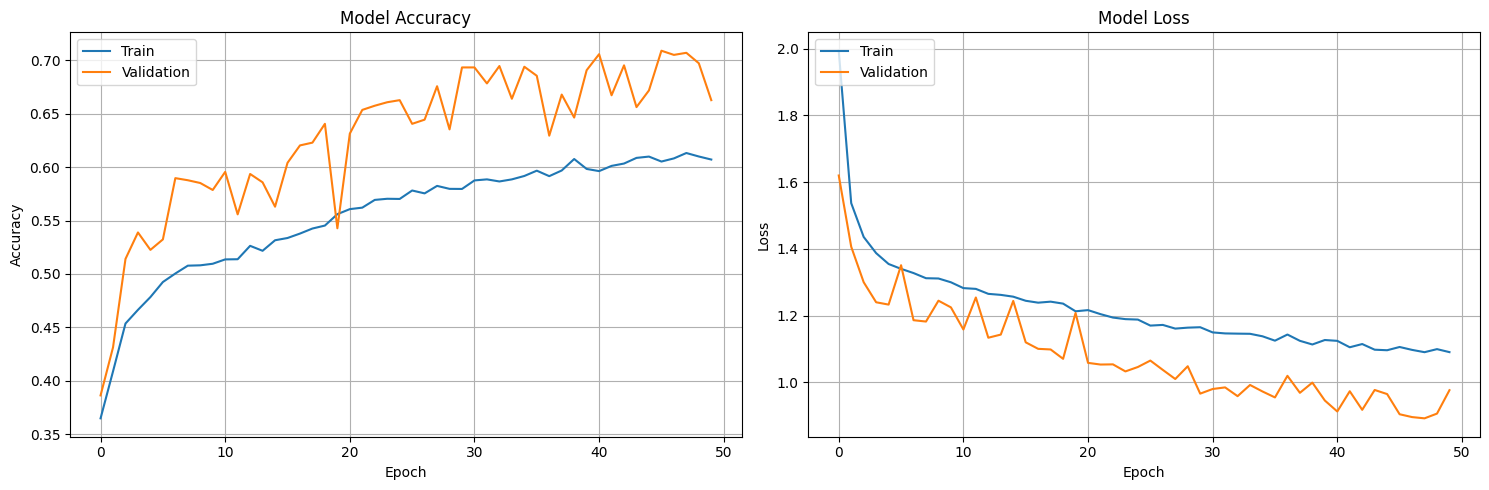

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


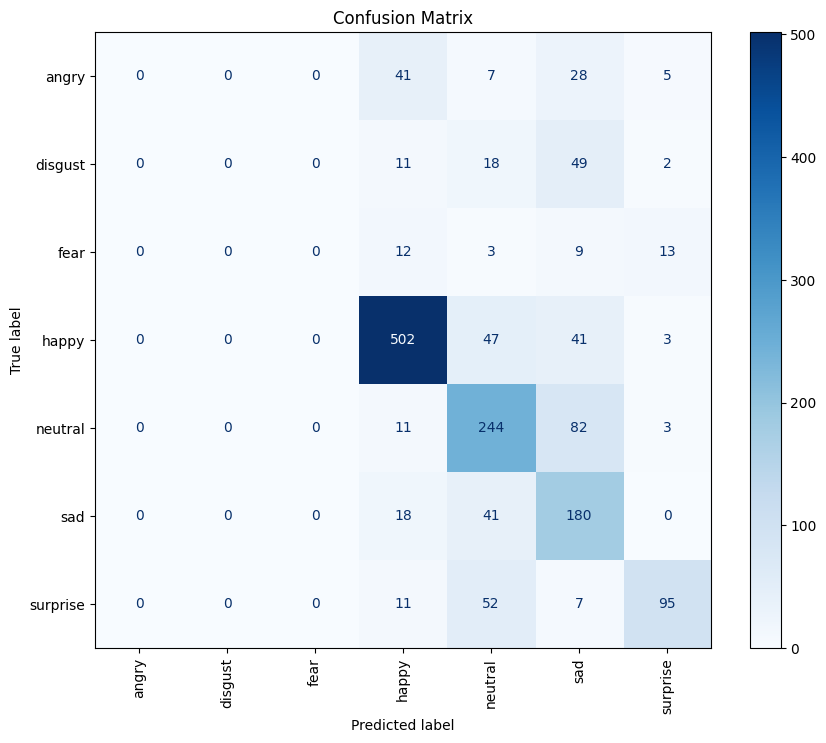

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = test.classes
y_pred_probabilities = model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000        81
     disgust     0.0000    0.0000    0.0000        80
        fear     0.0000    0.0000    0.0000        37
       happy     0.8284    0.8465    0.8374       593
     neutral     0.5922    0.7176    0.6489       340
         sad     0.4545    0.7531    0.5669       239
    surprise     0.7851    0.5758    0.6643       165

    accuracy                         0.6651      1535
   macro avg     0.3800    0.4133    0.3882      1535
weighted avg     0.6064    0.6651    0.6269      1535



En nuestro caso el modelo no tiene malas métricas, la precisión  de validación y entrenamiento crecen progresivamente, al igual que las funciones de pérdida disminuyen, sin evidencia clara de sobreajuste. Sin embargo, este es nuestro primer modelo, y se pueden aplicar algunas técnicas para mejorar las métricas.

# Búsqueda de hiperparámetros

Ahora con base a nuestro modelo anterior, vamos a hacer una búsqueda de hiperparámetros utilizando `keras_tuner`. Esto nos va a permitir entrenar varios modelos cambiando algunos hiperparámetros de arquitectura. En este caso, cambiaremos el tamaño de los filtros convolucionales, la tasa de aprendizaje, entre otros. Utilizamos un random tuner para que escoja el número de combinaciones aleatorias que definamos, y de allí escoja la mejor. Existen muchas combinaciones posibles para hacer esta búsqueda, se encuentran en la [documentación oficial](https://keras.io/keras_tuner/). Finalmente también se suaviza un poco los pesos de las clases ya que se evidencia en la matriz de confusión que se dejan de lado algunas clases.

In [ ]:
classes = np.unique(y_train.values)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train.values
)
class_weight = dict(zip(classes, weights))

alpha = 0.5
class_weight_scaled = {
    k: v**alpha for k, v in class_weight.items()
}

In [17]:
%pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.6 MB/s eta 0:00:00


In [18]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([
        layers.Conv2D(
            filters=hp.Choice('filters_1', [32, 64]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu',
            input_shape=(100, 100, 1)
        ),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            filters=hp.Choice('filters_2', [64, 128]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.MaxPooling2D(2),

        layers.Flatten(),

        layers.Dense(
            units=hp.Choice('dense_units', [64, 128, 256]),
            activation='relu'
        ),

        layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1)),

        layers.Dense(7, activation='softmax')
    ])

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    directory='tuner_dir',
    project_name='cnn_gen_tune'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = tuner.search(
    train,
    validation_data=val,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight_scaled
)

Trial 8 Complete [00h 03m 21s]
val_accuracy: 0.6901500225067139

Best val_accuracy So Far: 0.7462491989135742
Total elapsed time: 00h 29m 21s


In [21]:
best_model = tuner.get_best_models(1)[0]

history = best_model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_scaled
)
test_loss, test_acc = best_model.evaluate(test)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.6759 - loss: 0.9077 - val_accuracy: 0.7365 - val_loss: 0.7477 - learning_rate: 5.0000e-04
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.6857 - loss: 0.8823 - val_accuracy: 0.7515 - val_loss: 0.7194 - learning_rate: 5.0000e-04
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.6859 - loss: 0.8664 - val_accuracy: 0.7639 - val_loss: 0.7033 - learning_rate: 5.0000e-04
Epoch 4/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.6985 - loss: 0.8426 - val_accuracy: 0.7613 - val_loss: 0.6889 - learning_rate: 5.0000e-04
Epoch 5/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6991 - loss: 0.8339 - val_accuracy: 0.7528 - val_loss: 0.7063 - learning_rate: 5.0000e-04
Epoch 6/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.7026 - loss: 0.8247 - val_accuracy: 0.7593 - val_loss: 0.6864 - learning_rate: 5.0000e-04
Epoch 7/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accurac

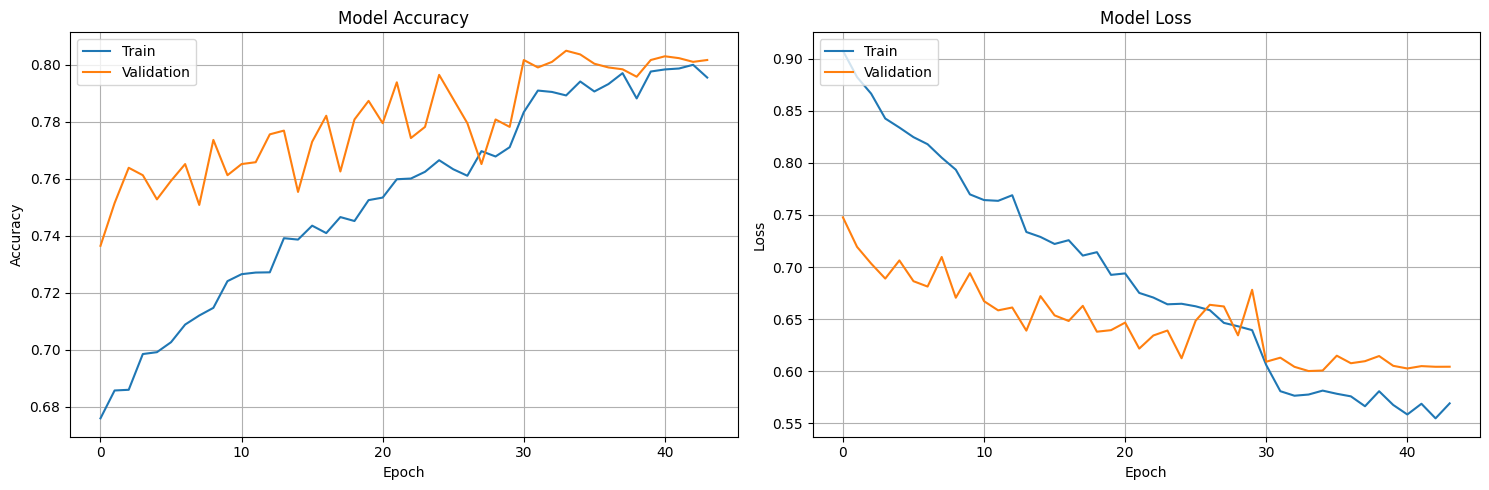

In [22]:
plot_training_history(history)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


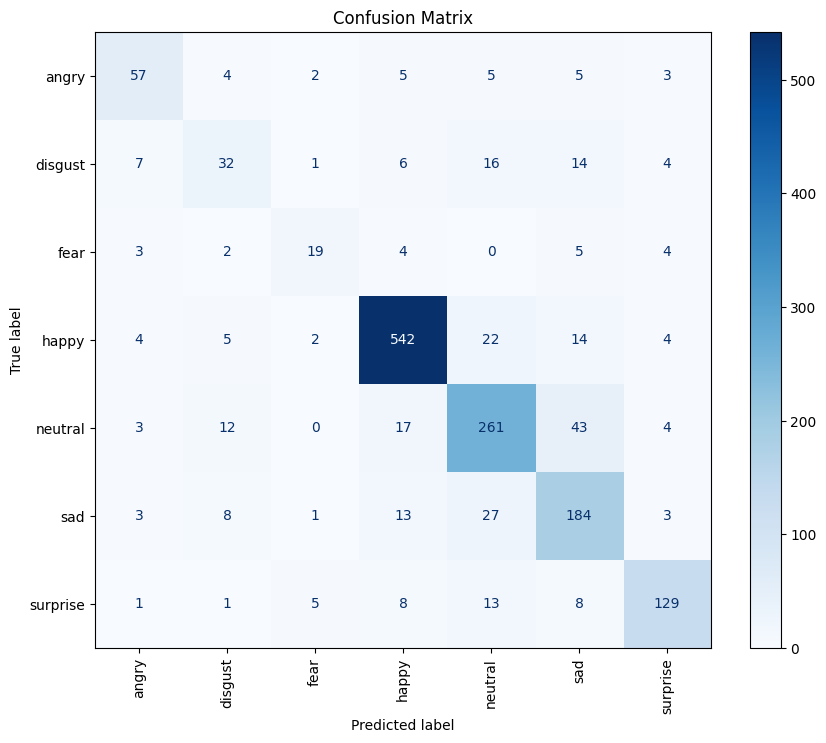

In [23]:
y_true = test.classes
y_pred_probabilities = best_model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [24]:
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

       angry     0.7308    0.7037    0.7170        81
     disgust     0.5000    0.4000    0.4444        80
        fear     0.6333    0.5135    0.5672        37
       happy     0.9109    0.9140    0.9125       593
     neutral     0.7587    0.7676    0.7632       340
         sad     0.6740    0.7699    0.7188       239
    surprise     0.8543    0.7818    0.8165       165

    accuracy                         0.7974      1535
   macro avg     0.7231    0.6929    0.7056      1535
weighted avg     0.7966    0.7974    0.7959      1535



## Conclusiones y Discusión

- **¿Cómo afecta el tamaño del filtro en las capas convolucionales al rendimiento del modelo?**  

- **¿Qué ventajas y desventajas presentan las diferentes estrategias de pooling (MaxPooling, AveragePooling, GlobalPooling) en la extracción de características?**  

- **¿Cómo influye la profundidad de la red (número de capas convolucionales) en la capacidad de generalización y el riesgo de sobreajuste?**  

- **¿Qué impacto tiene el uso de técnicas como Dropout o Batch Normalization en el entrenamiento de redes convolucionales?**  

- **¿Por qué es importante hacer la búsqueda de hiperparámetros?**  